# The BFGS Method

**Course:** Advanced Numerical Optimization (20.IDI16) · **Mentor:** Prof. Marko Miladinović · **Author:** Elvir Muslić

The notebook implements the BFGS method with a strong Wolfe line search, reproduces the computed update of the seminar paper,
checks the properties of the update at every step of a run, and compares BFGS with steepest descent on the Rosenbrock function
and on six test functions ported from Vilin, the optimization framework of the course. Every number quoted in the paper comes
from this run. Run with `.venv/bin/jupyter nbconvert --to notebook --execute --inplace bfgs_project.ipynb`; the run rewrites
the figures in `figures/` and the key numbers in `results.json`.

Sections: 1 Introduction, 2 Newton's method and the secant condition, 3 The BFGS update, 4 A computed update,
5 Line search and stopping test, 6 Experiments, 7 Conclusion.

## 1. Introduction

Setup: imports, the `check` helper that stops the run when a reproduced value or a verified property is off, the figure style
of the paper (one column, about 5 in wide) and the `RESULTS` dictionary written to `results.json` at the end.

In [1]:
import json
import platform
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

T_START = time.perf_counter()
np.seterr(over="ignore", invalid="ignore")      # a wild trial step may overflow f; the line search rejects it
rng = np.random.default_rng(16)
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
RESULTS = {"versions": {"python": platform.python_version(), "numpy": np.__version__, "matplotlib": plt.matplotlib.__version__}}
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "font.size": 8, "axes.titlesize": 9, "axes.labelsize": 8,
                     "legend.fontsize": 7, "xtick.labelsize": 7, "ytick.labelsize": 7, "lines.linewidth": 1.2,
                     "axes.grid": True, "grid.linestyle": ":", "grid.alpha": 0.6, "pdf.fonttype": 42})
COLORS = {"Steepest descent": "0.45", "BFGS": "C0"}
def check(condition, message):
    """Fail loudly if a verification does not hold; otherwise print it."""
    assert condition, f"check failed: {message}"
    print(f"check: {message} ✓")
def save_figure(fig, name):
    fig.savefig(FIG_DIR / name, bbox_inches="tight")
    RESULTS.setdefault("figures", []).append(f"figures/{name}")

## 2. Newton's method and the secant condition

With $s_k = x_{k+1} - x_k$ and $y_k = \nabla f_{k+1} - \nabla f_k$, the next inverse Hessian approximation must satisfy the
secant equation $H_{k+1} y_k = s_k$, which has a symmetric positive definite solution only if $s_k^\top y_k > 0$. The paper
proves that a step satisfying the strong Wolfe conditions gives $s_k^\top y_k \ge (c_2 - 1)\,\alpha_k \nabla f_k^\top p_k > 0$
(Lemma 2.1). Section 6 checks this bound at every accepted step of the runs.

## 3. The BFGS update

`bfgs_update` applies the update (6.17) of Nocedal and Wright in the rank-two form $H + s w^\top + w s^\top$ with
$w = \tfrac12 \rho (1 + \rho\, y^\top H y)\, s - \rho\, H y$: one matrix-vector product and two outer products, $O(n^2)$
operations. Theorem 3.1 of the paper (symmetry, secant equation, positive definiteness) is checked after every update of the
run in Section 6; `cholesky_ok` is its positive definiteness test.

In [2]:
def bfgs_update(H, s, y):
    """Update (6.17) of H in place, expanded to the rank-two correction H + s w^T + w s^T (O(n^2) work)."""
    rho = 1.0 / (y @ s)
    Hy = H @ y
    w = 0.5 * rho * (1.0 + rho * (y @ Hy)) * s - rho * Hy
    H += np.outer(s, w) + np.outer(w, s)
    return H

def cholesky_ok(H):
    """Positive definiteness test: the Cholesky factorization of H succeeds."""
    try:
        return np.linalg.cholesky(H) is not None
    except np.linalg.LinAlgError:
        return False

## 4. A computed update

The example of the paper: $H_k = I$, $s_k = (1, 0)^\top$, $y_k = (2, 1)^\top$, so $\rho_k = 1/2$ and
$H_{k+1} = \begin{pmatrix} 3/4 & -1/2 \\ -1/2 & 1 \end{pmatrix}$ with eigenvalues $(7 \pm \sqrt{17})/8$. The product form
(6.17) and the rank-two form used by the solver must both give this matrix exactly.

In [3]:
s_w, y_w = np.array([1.0, 0.0]), np.array([2.0, 1.0])
V_w = np.eye(2) - np.outer(y_w, s_w) / (y_w @ s_w)
H_prod = V_w.T @ np.eye(2) @ V_w + np.outer(s_w, s_w) / (y_w @ s_w)      # product form (6.17) with H_k = I
H_w = bfgs_update(np.eye(2), s_w, y_w)                                   # rank-two form used by the solver
eig_w = np.linalg.eigvalsh(H_w)
print("H_{k+1} =\n", H_w, "\neigenvalues:", eig_w)
check(np.array_equal(H_prod, [[0.75, -0.5], [-0.5, 1.0]]), "product form (6.17) gives H_{k+1} = [[3/4, -1/2], [-1/2, 1]] exactly")
check(np.array_equal(H_w, H_prod), "the rank-two form of the solver gives the same matrix exactly")
check(np.array_equal(H_w @ y_w, s_w) and cholesky_ok(H_w), "secant equation H_{k+1} y = s with residual 0; Cholesky succeeds")
check(np.allclose(eig_w, [0.3596, 1.3904], atol=5e-5), f"eigenvalues {eig_w[0]:.4f} and {eig_w[1]:.4f}, both positive")
RESULTS["hand_update"] = {"H_next": H_w.tolist(), "eigenvalues": eig_w.tolist(), "secant_residual": float(np.linalg.norm(H_w @ y_w - s_w))}

H_{k+1} =
 [[ 0.75 -0.5 ]
 [-0.5   1.  ]] 
eigenvalues: [0.3596118 1.3903882]
check: product form (6.17) gives H_{k+1} = [[3/4, -1/2], [-1/2, 1]] exactly ✓
check: the rank-two form of the solver gives the same matrix exactly ✓
check: secant equation H_{k+1} y = s with residual 0; Cholesky succeeds ✓
check: eigenvalues 0.3596 and 1.3904, both positive ✓


## 5. Line search and stopping test

`strong_wolfe` is Algorithm 3.5 of Nocedal and Wright with the `zoom` of Algorithm 3.6, for the strong Wolfe conditions
(3.7) with $c_1 = 10^{-4}$ and $c_2 = 0.9$. Inside a bracket the trial step minimizes the quadratic through the two end
values and the slope at $\alpha_{\mathrm{lo}}$, with bisection as a safeguard. The gradient at a trial point is evaluated
only after the sufficient decrease condition holds there.

`minimize` runs steepest descent (`"sd"`) or BFGS (`"bfgs"`). The first trial step is $\min(1, 1/\|\nabla f_0\|)$; after
that BFGS tries $\alpha = 1$ first and steepest descent tries
$\alpha_{k-1} \nabla f_{k-1}^\top p_{k-1} / \nabla f_k^\top p_k$. BFGS takes its first step along $-\nabla f_0$ and sets
$H_0 = (y_0^\top s_0 / y_0^\top y_0)\, I$ before the first update (6.20). The run stops when
$\|\nabla f_k\| \le \varepsilon \max(1, \|x_k\|)$ with $\varepsilon = 10^{-5}$, or at the iteration cap.

In [4]:
def strong_wolfe(F, G, x, p, f0, g0, alpha0, c1=1e-4, c2=0.9, max_iter=60):
    """Algorithm 3.5 with the zoom of Algorithm 3.6: returns alpha, f and g at x + alpha p, and a success flag."""
    d0 = g0 @ p

    def zoom(lo, hi):                       # lo = (a, f, d, g) with sufficient decrease; hi = (a, f)
        for _ in range(max_iter):
            h = hi[0] - lo[0]
            c = (hi[1] - lo[1] - lo[2] * h) / h**2 if np.isfinite(hi[1]) else 0.0   # quadratic through lo, hi
            a = lo[0] - lo[2] / (2.0 * c) if c > 0.0 else lo[0] + 0.5 * h
            a = a if 0.1 <= (a - lo[0]) / h <= 0.9 else lo[0] + 0.5 * h              # safeguard: bisection
            fa = F(x + a * p)
            if not fa <= f0 + c1 * a * d0 or fa >= lo[1]:         # a non-finite fa counts as too large
                hi = (a, fa)
            else:
                da = (ga := G(x + a * p)) @ p
                if abs(da) <= -c2 * d0:
                    return a, fa, ga, True
                if da * (hi[0] - lo[0]) >= 0.0:
                    hi = lo[:2]
                lo = (a, fa, da, ga)
            if abs(hi[0] - lo[0]) <= 1e-16 * max(1.0, abs(lo[0])):
                break
        return lo[0], lo[1], lo[3], False

    prev, a = (0.0, f0, d0, g0), alpha0
    for i in range(max_iter):
        fa = F(x + a * p)
        if not fa <= f0 + c1 * a * d0 or (i > 0 and fa >= prev[1]):
            return zoom(prev, (a, fa))
        da = (ga := G(x + a * p)) @ p
        if abs(da) <= -c2 * d0:
            return a, fa, ga, True
        if da >= 0.0:
            return zoom((a, fa, da, ga), prev[:2])
        prev, a = (a, fa, da, ga), 2.0 * a
    return prev[0], prev[1], prev[3], False

def minimize(fun, grad, x0, method, eps=1e-5, max_iter=10_000, trace=False):
    """Steepest descent ("sd") or BFGS ("bfgs") from x0; stops when ||g_k|| <= eps max(1, ||x_k||) or at max_iter."""
    calls = [0, 0]                                            # evaluations of f and of its gradient
    def F(z): calls[0] += 1; return float(fun(z))
    def G(z): calls[1] += 1; return grad(z)
    x = np.array(x0, dtype=float)
    f, g = F(x), G(x)
    H, prev, steps, xs, hist = None, None, [], [x.copy()], [np.linalg.norm(g)]
    k, status = 0, "converged"
    while hist[-1] > eps * max(1.0, np.linalg.norm(x)):
        if k == max_iter:
            status = "max_iter"
            break
        p = -g if H is None else -H @ g
        if g @ p >= 0.0:                                      # not a descent direction (rounding): restart
            p, H = -g, None
        alpha0 = min(1.0, 1.0 / hist[0]) if k == 0 else (prev[0] * prev[1] / (g @ p) if method == "sd" else 1.0)
        alpha, f_new, g_new, _ = strong_wolfe(F, G, x, p, f, g, alpha0)
        if alpha == 0.0:
            status = "line_search"
            break
        s, y, prev = alpha * p, g_new - g, (alpha, g @ p)
        updated = method == "bfgs" and s @ y > 1e-12 * np.linalg.norm(s) * np.linalg.norm(y)   # else skip the update
        if updated:
            if H is None:
                H = np.eye(x.size) * (s @ y) / (y @ y)        # H_0 = I, scaled by (6.20) before the first update
            bfgs_update(H, s, y)
        if trace:
            steps.append({"alpha": alpha, "f": f, "slope": g @ p, "f_new": f_new, "slope_new": g_new @ p,
                          "s": s, "y": y, "H": H.copy() if updated else None})
            xs.append(x + s)
        x, f, g, k = x + s, f_new, g_new, k + 1
        hist.append(np.linalg.norm(g))
    return {"x": x, "f": f, "iterations": k, "nfev": calls[0], "ngev": calls[1], "status": status,
            "gnorm_history": hist, "x_history": xs, "steps": steps, "H_bytes": 0 if H is None else H.nbytes}

## 6. Experiments

### The test functions

Six functions ported from Vilin (`Functions/MultiDimensional/*.m`, MIT License) with Vilin's starting points
(`Util/StartingPointGenerator.m`) and their known optimal values $f^*$. They are defined first because the Rosenbrock
function of part (a) is ExtRosenbrock with $n = 2$. Each gradient is checked against a central finite difference at
$n = 10$, at the starting point and at three random points near it.

In [5]:
idx = lambda x: np.arange(1, x.size + 1, dtype=float)             # the index vector (1, ..., n)

ext_rosenbrock = lambda x: np.sum(100.0 * (x[1::2] - x[0::2] ** 2) ** 2 + (1.0 - x[0::2]) ** 2)
def ext_rosenbrock_grad(x):
    g, xo, xe = np.empty_like(x), x[0::2], x[1::2]
    g[0::2], g[1::2] = -400.0 * xo * (xe - xo**2) - 2.0 * (1.0 - xo), 200.0 * (xe - xo**2)
    return g

ext_white_holst = lambda x: np.sum(100.0 * (x[1::2] - x[0::2] ** 3) ** 2 + (1.0 - x[0::2]) ** 2)
def ext_white_holst_grad(x):
    g, xo, xe = np.empty_like(x), x[0::2], x[1::2]
    g[0::2], g[1::2] = -600.0 * xo**2 * (xe - xo**3) - 2.0 * (1.0 - xo), 200.0 * (xe - xo**3)
    return g

liarwhd = lambda x: np.sum(4.0 * (x**2 - x[0]) ** 2 + (x - 1.0) ** 2)
def liarwhd_grad(x):
    t = x**2 - x[0]
    g = 16.0 * x * t + 2.0 * (x - 1.0)
    g[0] -= 8.0 * np.sum(t)
    return g

diagonal1 = lambda x: np.sum(np.exp(x) - idx(x) * x)
diagonal1_grad = lambda x: np.exp(x) - idx(x)

pert_quad = lambda x: np.sum(idx(x) * x**2) + np.sum(x) ** 2 / 100.0
pert_quad_grad = lambda x: 2.0 * idx(x) * x + 2.0 * np.sum(x) / 100.0

tridia = lambda x: (x[0] - 1.0) ** 2 + np.sum(idx(x)[1:] * (2.0 * x[1:] - x[:-1]) ** 2)
def tridia_grad(x):
    g, r = np.zeros_like(x), idx(x)[1:] * (2.0 * x[1:] - x[:-1])
    g[0], g[1:] = 2.0 * (x[0] - 1.0), 4.0 * r
    g[:-1] -= 2.0 * r
    return g

TEST_SET = {   # name: (f, gradient, Vilin starting point, known optimal value f*)
    "ExtRosenbrock": (ext_rosenbrock, ext_rosenbrock_grad, lambda n: np.resize([-1.2, 1.0], n), lambda n: 0.0),
    "ExtWhiteHolst": (ext_white_holst, ext_white_holst_grad, lambda n: np.resize([-1.2, 1.0], n), lambda n: 0.0),
    "LIARWHD": (liarwhd, liarwhd_grad, lambda n: np.full(n, 4.0), lambda n: 0.0),
    "Diagonal1": (diagonal1, diagonal1_grad, lambda n: np.full(n, 1.0 / n),
                  lambda n: float(np.sum(np.arange(1, n + 1) * (1.0 - np.log(np.arange(1, n + 1)))))),
    "PertQuad": (pert_quad, pert_quad_grad, lambda n: np.full(n, 0.5), lambda n: 0.0),
    "TRIDIA": (tridia, tridia_grad, lambda n: np.full(n, 1.0), lambda n: 0.0),
}

def fd_gradient(fun, x, h=1e-6):
    """Central finite difference with step h max(1, |x_i|) in coordinate i."""
    E = np.diag(h * np.maximum(1.0, np.abs(x)))
    return np.array([(fun(x + e) - fun(x - e)) / (2.0 * e.sum()) for e in E])

grad_err = {}
for name, (f, g, x0f, fs) in TEST_SET.items():
    pts = [x0f(10)] + [x0f(10) + 0.3 * rng.standard_normal(10) for _ in range(3)]
    grad_err[name] = max(np.linalg.norm(fd_gradient(f, x) - g(x)) / max(1.0, np.linalg.norm(g(x))) for x in pts)
    print(f"{name:14s} largest relative error against central finite differences: {grad_err[name]:.1e}")
check(max(grad_err.values()) <= 1e-6, f"the six gradients agree with finite differences (worst {max(grad_err.values()):.1e})")
RESULTS["gradient_check"] = grad_err

ExtRosenbrock  largest relative error against central finite differences: 1.0e-10
ExtWhiteHolst  largest relative error against central finite differences: 1.3e-10
LIARWHD        largest relative error against central finite differences: 1.5e-10
Diagonal1      largest relative error against central finite differences: 1.4e-10
PertQuad       largest relative error against central finite differences: 1.9e-10
TRIDIA         largest relative error against central finite differences: 1.8e-10
check: the six gradients agree with finite differences (worst 1.9e-10) ✓


### (a) Rosenbrock, n = 2

Both methods start from $x_0 = (-1.2, 1)$ and run to the tight test $\|\nabla f_k\| \le 10^{-10} \max(1, \|x_k\|)$, so
that the tail of the convergence is visible; the iteration at which the standard test of Section 5 is first met is read off
the same run. Figure 1 shows the BFGS path over the contours, Figure 2 the gradient norm per iteration. The run records every
accepted step, so the strong Wolfe conditions, the bound of Lemma 2.1 and Theorem 3.1 are checked at every step. The last
five ratios $\|x_{k+1} - x^*\| / \|x_k - x^*\|$ separate superlinear from linear convergence: for BFGS they tend to zero,
not monotonically, so their geometric mean is compared with the steepest-descent ratios, which stay near one.

Steepest descent  converged: 18981 iterations to the tight test, 8098 to the standard test, ||x - x*|| = 3.1e-10; last five ratios 0.9995, 0.9983, 0.9995, 0.9984, 0.9995
BFGS              converged: 40 iterations to the tight test, 39 to the standard test, ||x - x*|| = 2.0e-13; last five ratios 0.0947, 0.0524, 0.1286, 0.0001, 0.0007


check: Steepest descent: both strong Wolfe conditions hold at every one of the 18981 accepted steps ✓
check: Steepest descent: s^T y >= (c2 - 1) alpha g^T p > 0 at every accepted step (Lemma 2.1) ✓
check: BFGS: both strong Wolfe conditions hold at every one of the 40 accepted steps ✓
check: BFGS: s^T y >= (c2 - 1) alpha g^T p > 0 at every accepted step (Lemma 2.1) ✓
check: after every one of the 40 BFGS updates H is symmetric (asymmetry 0.0e+00), satisfies H y = s (relative residual <= 4.7e-15) and is positive definite (Cholesky) ✓
check: BFGS reaches x* = (1, 1): ||x - x*|| = 2.0e-13 <= 1e-6 ✓
check: last five ratios: BFGS geometric mean 0.0087 < 0.1, each below the steepest-descent ratios, which stay above 0.99 (Hessian condition number at x*: 2508, linear bound (k - 1)/(k + 1) = 0.9992) ✓


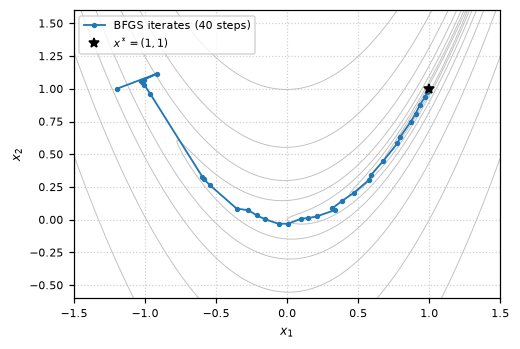

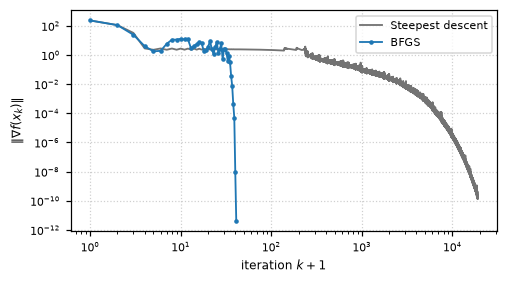

In [6]:
f_r, g_r, x0f_r, _ = TEST_SET["ExtRosenbrock"]
runs = {label: minimize(f_r, g_r, x0f_r(2), method=m, eps=1e-10, max_iter=30_000, trace=True)
        for label, m in (("Steepest descent", "sd"), ("BFGS", "bfgs"))}
err = {label: np.linalg.norm(np.array(r["x_history"]) - 1.0, axis=1) for label, r in runs.items()}
ratios = {label: e[1:] / e[:-1] for label, e in err.items()}
std_iter = {label: int(np.argmax(np.array(r["gnorm_history"]) <= 1e-5 * np.maximum(1.0, np.linalg.norm(r["x_history"], axis=1))))
            for label, r in runs.items()}
for label, r in runs.items():
    print(f"{label:17s} {r['status']}: {r['iterations']} iterations to the tight test, {std_iter[label]} to the standard test, "
          f"||x - x*|| = {err[label][-1]:.1e}; last five ratios " + ", ".join(f"{q:.4f}" for q in ratios[label][-5:]))

fig, ax = plt.subplots(figsize=(5.0, 3.4))
X1, X2 = np.meshgrid(np.linspace(-1.5, 1.5, 301), np.linspace(-0.6, 1.6, 301))
ax.contour(X1, X2, 100.0 * (X2 - X1**2) ** 2 + (1.0 - X1) ** 2, levels=np.logspace(-1, 3, 9), colors="0.75", linewidths=0.6)
path = np.array(runs["BFGS"]["x_history"])
ax.plot(path[:, 0], path[:, 1], "o-", color=COLORS["BFGS"], ms=2.5, label=f"BFGS iterates ({len(path) - 1} steps)")
ax.plot(1.0, 1.0, "k*", ms=7, label="$x^* = (1, 1)$")
ax.set(xlabel="$x_1$", ylabel="$x_2$")
ax.legend(loc="upper left")
save_figure(fig, "rosenbrock_path.pdf")

fig, ax = plt.subplots(figsize=(5.0, 2.6))
for label, r in runs.items():
    ax.loglog(np.arange(1, len(r["gnorm_history"]) + 1), r["gnorm_history"], "o-" if label == "BFGS" else "-", ms=2, color=COLORS[label], label=label)
ax.set(xlabel="iteration $k + 1$", ylabel=r"$\|\nabla f(x_k)\|$")
ax.legend()
save_figure(fig, "rosenbrock_convergence.pdf")

c1, c2 = 1e-4, 0.9
for label, r in runs.items():
    st = r["steps"]
    check(all(s["f_new"] <= s["f"] + c1 * s["alpha"] * s["slope"] and abs(s["slope_new"]) <= c2 * abs(s["slope"]) for s in st),
          f"{label}: both strong Wolfe conditions hold at every one of the {len(st)} accepted steps")
    check(all(s["s"] @ s["y"] >= (c2 - 1.0) * s["alpha"] * s["slope"] > 0.0 for s in st),
          f"{label}: s^T y >= (c2 - 1) alpha g^T p > 0 at every accepted step (Lemma 2.1)")
Hs = [(s["H"], s["s"], s["y"]) for s in runs["BFGS"]["steps"] if s["H"] is not None]     # one update per step
asym_max = max(np.max(np.abs(H - H.T)) / np.max(np.abs(H)) for H, s, y in Hs)
sec_max = max(np.linalg.norm(H @ y - s) / np.linalg.norm(s) for H, s, y in Hs)
check(len(Hs) == len(runs["BFGS"]["steps"]) and asym_max <= 1e-15 and sec_max <= 1e-10 and all(cholesky_ok(H) for H, s, y in Hs),
      f"after every one of the {len(Hs)} BFGS updates H is symmetric (asymmetry {asym_max:.1e}), satisfies H y = s "
      f"(relative residual <= {sec_max:.1e}) and is positive definite (Cholesky)")
check(err["BFGS"][-1] <= 1e-6, f"BFGS reaches x* = (1, 1): ||x - x*|| = {err['BFGS'][-1]:.1e} <= 1e-6")
gm, kappa = float(np.exp(np.mean(np.log(ratios["BFGS"][-5:])))), float(np.linalg.cond([[802.0, -400.0], [-400.0, 200.0]]))
check(gm < 0.1 and ratios["BFGS"][-5:].max() < ratios["Steepest descent"][-5:].min() and np.all(ratios["Steepest descent"][-5:] > 0.99),
      f"last five ratios: BFGS geometric mean {gm:.4f} < 0.1, each below the steepest-descent ratios, which stay above 0.99 "
      f"(Hessian condition number at x*: {kappa:.0f}, linear bound (k - 1)/(k + 1) = {(kappa - 1) / (kappa + 1):.4f})")
RESULTS["rosenbrock"] = {label: {"status": r["status"], "iterations_eps_1e-10": r["iterations"], "iterations_eps_1e-5": std_iter[label],
                                 "nfev": r["nfev"], "ngev": r["ngev"], "final_error": float(err[label][-1]),
                                 "last_five_ratios": ratios[label][-5:].tolist()} for label, r in runs.items()}
RESULTS["rosenbrock"]["BFGS"].update({"max_asymmetry": asym_max, "max_secant_residual": sec_max, "geomean_last_five_ratios": gm})
RESULTS["rosenbrock"]["hessian_condition_number_at_xstar"] = kappa

### (b) Six test functions at n = 100 and n = 1000

Both methods from Vilin's starting points. Steepest descent is capped at 10 000 iterations and marked when it does not
converge. Every converged run must reach the known optimal value $f^*$: the relative gap $(f - f^*) / \max(1, |f^*|)$ is
bounded by a stated tolerance.

In [7]:
CAP, GAP_TOL = 10_000, 1e-6
bench = []
for n_b in (100, 1000):
    for name, (f, g, x0f, fs) in TEST_SET.items():
        for label, m in (("Steepest descent", "sd"), ("BFGS", "bfgs")):
            r = minimize(f, g, x0f(n_b), method=m, max_iter=CAP)
            bench.append({"n": n_b, "problem": name, "method": label, "status": r["status"], "iterations": r["iterations"],
                          "evaluations": r["nfev"] + r["ngev"], "f": r["f"], "H_bytes": r["H_bytes"],
                          "gap": (r["f"] - fs(n_b)) / max(1.0, abs(fs(n_b)))})
print(f"{'problem':14s} {'n':>5s} {'method':17s} {'status':10s} {'iters':>6s} {'f+g':>6s} {'rel. gap':>9s}")
for b in bench:
    print(f"{b['problem']:14s} {b['n']:5d} {b['method']:17s} {b['status']:10s} {b['iterations']:6d} {b['evaluations']:6d} {b['gap']:9.1e}")
solved, unsolved = [b for b in bench if b["status"] == "converged"], [b for b in bench if b["status"] != "converged"]
check(all(b["status"] == "converged" for b in bench if b["method"] == "BFGS"), "BFGS solves all 12 problems")
check(all(b["method"] == "Steepest descent" and b["iterations"] == CAP for b in unsolved),
      f"{len(unsolved)} runs do not converge, all of them steepest descent stopped at the cap of {CAP} iterations")
check(all(abs(b["gap"]) <= GAP_TOL for b in solved),
      f"every solved run reaches f* to a relative gap of {GAP_TOL:.0e} (worst {max(abs(b['gap']) for b in solved):.1e})")
RESULTS["benchmark"] = {"cap": CAP, "gap_tolerance": GAP_TOL, "runs": bench}

problem            n method            status      iters    f+g  rel. gap
ExtRosenbrock    100 Steepest descent  converged    8387  17095   9.5e-09
ExtRosenbrock    100 BFGS              converged      38     93   3.0e-13
ExtWhiteHolst    100 Steepest descent  max_iter    10000  20173   1.4e-03
ExtWhiteHolst    100 BFGS              converged      42     99   8.3e-14
LIARWHD          100 Steepest descent  converged    1328   2790   1.7e-09
LIARWHD          100 BFGS              converged      20     42   5.0e-16
Diagonal1        100 Steepest descent  converged     149    338   1.5e-12
Diagonal1        100 BFGS              converged      51    173   7.9e-14
PertQuad         100 Steepest descent  converged     348    743   1.7e-11
PertQuad         100 BFGS              converged      72    146   7.1e-13
TRIDIA           100 Steepest descent  converged    4080   8503   3.1e-11
TRIDIA           100 BFGS              converged      81    170   4.3e-13
ExtRosenbrock   1000 Steepest descent 

### (c) Storage and cost

BFGS stores the dense matrix $H_k$: $n^2$ numbers, $8n^2$ bytes in double precision. Each iteration costs $O(n^2)$
operations: the product $H_k \nabla f_k$ and the rank-two update of Section 3.

In [8]:
n_s = 1000
check(all(b["H_bytes"] == 8 * n_s**2 for b in bench if b["method"] == "BFGS" and b["n"] == n_s),
      f"at n = {n_s} the matrix H of every BFGS run takes n^2 = {n_s**2} numbers, {8 * n_s**2} bytes")
RESULTS["storage"] = {"n": n_s, "H_numbers": n_s**2, "H_bytes": 8 * n_s**2}

check: at n = 1000 the matrix H of every BFGS run takes n^2 = 1000000 numbers, 8000000 bytes ✓


Write `results.json` and check that every number quoted in the paper, the README and the conclusion below equals the value
computed in this run, rounded as quoted there.

In [9]:
RESULTS["runtime_seconds"] = round(time.perf_counter() - T_START, 1)
Path("results.json").write_text(json.dumps(RESULTS, indent=2, ensure_ascii=False) + "\n")
print(f"results.json written; figures: {RESULTS['figures']}; runtime {RESULTS['runtime_seconds']} s")

QUOTED = {"eigenvalues": [0.3596, 1.3904], "secant_residual": 0.0, "grad_err": 1.9e-10, "condition_number": 2508, "linear_bound": 0.9992,
          "iterations_eps_1e-5": {"Steepest descent": 8098, "BFGS": 39}, "iterations_eps_1e-10": {"Steepest descent": 18981, "BFGS": 40},
          "final_error": {"Steepest descent": 3.1e-10, "BFGS": 2.0e-13}, "max_secant_residual": 4.7e-15, "geomean_ratios": 0.0087,
          "ratios": {"Steepest descent": [0.9995, 0.9983, 0.9995, 0.9984, 0.9995], "BFGS": [0.095, 0.052, 0.13, 0.00011, 0.00071]},
          "table": {"ExtRosenbrock@100": [8387, 17095, 38, 93], "ExtWhiteHolst@100": [10000, 20173, 42, 99], "LIARWHD@100": [1328, 2790, 20, 42],
                    "Diagonal1@100": [149, 338, 51, 173], "PertQuad@100": [348, 743, 72, 146], "TRIDIA@100": [4080, 8503, 81, 170],
                    "ExtRosenbrock@1000": [8402, 17131, 38, 104], "ExtWhiteHolst@1000": [10000, 20157, 44, 97], "LIARWHD@1000": [10000, 20271, 22, 48],
                    "Diagonal1@1000": [1117, 2376, 138, 437], "PertQuad@1000": [3639, 7519, 248, 500], "TRIDIA@1000": [10000, 20160, 312, 946]},
          "unsolved": 4, "max_bfgs_iterations": 312, "worst_gap": 9.6e-8, "H_numbers": 1000000, "H_bytes": 8000000,
          "versions": {"python": "3.14.1", "numpy": "2.5.0", "matplotlib": "3.11.0"}, "runtime_below_10_s": True}
R, B, M = RESULTS["rosenbrock"], RESULTS["benchmark"]["runs"], ("Steepest descent", "BFGS")
sig = lambda v, d: float(f"{v:.{d}e}")                      # round to d + 1 significant digits
tab = {k: [v for b in B if f"{b['problem']}@{b['n']}" == k for v in (b["iterations"], b["evaluations"])] for k in QUOTED["table"]}
computed = {"eigenvalues": [round(v, 4) for v in RESULTS["hand_update"]["eigenvalues"]], "secant_residual": RESULTS["hand_update"]["secant_residual"],
            "grad_err": sig(max(RESULTS["gradient_check"].values()), 1), "condition_number": round(kappa), "linear_bound": round((kappa - 1) / (kappa + 1), 4),
            "iterations_eps_1e-5": {m: R[m]["iterations_eps_1e-5"] for m in M}, "iterations_eps_1e-10": {m: R[m]["iterations_eps_1e-10"] for m in M},
            "final_error": {m: sig(R[m]["final_error"], 1) for m in M}, "max_secant_residual": sig(R["BFGS"]["max_secant_residual"], 1),
            "geomean_ratios": round(R["BFGS"]["geomean_last_five_ratios"], 4),
            "ratios": {"Steepest descent": [round(v, 4) for v in R["Steepest descent"]["last_five_ratios"]], "BFGS": [sig(v, 1) for v in R["BFGS"]["last_five_ratios"]]},
            "table": tab, "unsolved": sum(b["status"] != "converged" for b in B), "max_bfgs_iterations": max(b["iterations"] for b in B if b["method"] == "BFGS"),
            "worst_gap": sig(max(abs(b["gap"]) for b in B if b["status"] == "converged"), 1), "H_numbers": RESULTS["storage"]["H_numbers"],
            "H_bytes": RESULTS["storage"]["H_bytes"], "versions": RESULTS["versions"], "runtime_below_10_s": RESULTS["runtime_seconds"] < 10}
check(computed == QUOTED, f"all {len(QUOTED)} entries quoted in the paper and the README match this run")

results.json written; figures: ['figures/rosenbrock_path.pdf', 'figures/rosenbrock_convergence.pdf']; runtime 3.6 s
check: all 19 entries quoted in the paper and the README match this run ✓


## 7. Conclusion

- **The implementation matches the theory.** The computed update of the paper is reproduced exactly from both forms of the
  formula, with secant residual 0 and eigenvalues 0.3596 and 1.3904. On the Rosenbrock function both strong Wolfe conditions
  and the bound of Lemma 2.1 hold at every accepted step of both methods, and after every one of the 40 BFGS updates $H$ is
  symmetric, satisfies $Hy = s$ (relative residual at most $4.7\cdot10^{-15}$) and has a Cholesky factorization.
- **Superlinear against linear.** BFGS meets the stopping test after 39 iterations and steepest descent after 8098
  (40 and 18 981 iterations to the tolerance $10^{-10}$, ending at $2.0\cdot10^{-13}$ and $3.1\cdot10^{-10}$ from $x^*$).
  The last five BFGS ratios 0.095, 0.052, 0.13, $1.1\cdot10^{-4}$ and $7.1\cdot10^{-4}$ have geometric mean 0.0087; the
  steepest-descent ratios 0.9995, 0.9983, 0.9995, 0.9984 and 0.9995 stay near the bound $(\kappa - 1)/(\kappa + 1) = 0.9992$
  for the condition number $\kappa = 2508$ of the Hessian at $x^*$.
- **Six Vilin functions.** The six gradients agree with central finite differences to $1.9\cdot10^{-10}$. BFGS solves all 12
  problems at $n = 100$ and $n = 1000$ in at most 312 iterations, every converged run reaches $f^*$ to a relative gap of at
  most $9.6\cdot10^{-8}$, and steepest descent stops at the cap of 10 000 iterations on 4 of the 12.
- **Storage.** At $n = 1000$ the matrix $H$ holds $10^6$ numbers, $8\cdot10^6$ bytes.